#Question 1: What is Boosting in Machine Learning? Explain how it improves weak learners.

**Ans:-** Boosting is an ensemble learning technique that combines many weak learners to create a strong learner.
A weak learner is a model that performs only slightly better than random guessing

#Question 2: What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?
**Answer:-** AdaBoost trains each model by reweighting training samples to focus on misclassified points, while Gradient Boosting trains each model to predict the residual errors (gradients of the loss function) of the current model.

#Question 3: How does regularization help in XGBoost?
**Ans:-** Regularization in XGBoost helps prevent overfitting by directly penalizing model complexity within its objective function. It uses L1 and L2 regularization to shrink leaf weights, making the model more stable and less sensitive to noise, while an additional penalty term discourages creating too many leaves, preventing overly complex trees.

#Question 4: Why is CatBoost considered efficient for handling categorical data?
**Ans:-** CatBoost is considered efficient for handling categorical data because it natively processes categorical features without requiring extensive preprocessing like one-hot encoding or label encoding. Instead, it uses target-based statistics with an ordered boosting technique, which replaces each category with values computed from the target in a way that avoids target leakage.

#Question 5: What are some real-world applications where boosting techniques are preferred over bagging methods?

**Ans:-** Real world applications boosting techniques are often preferred over bagging methods, where high predictive accuracy and fine-grained error correction are crucial.

They are widely used in areas like credit scoring and fraud detection.


In [1]:
#Question 6:
'''
 Write a Python program to:
● Train an AdaBoost Classifier on the Breast Cancer dataset
● Print the model accuracy
'''

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# 1. Load the Breast Cancer dataset
print("Loading dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the data into training and testing sets
# We use a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Data split into: Train samples ({len(X_train)}), Test samples ({len(X_test)})")

# 3. Initialize and train the AdaBoost Classifier
# AdaBoost is an ensemble method that combines multiple weak learners (by default, Decision Trees)
print("Training AdaBoost Classifier...")
adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost_model.fit(X_train, y_train)
print("Training complete.")

# 4. Evaluate the model on the test set
y_pred = adaboost_model.predict(X_test)

# 5. Print the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print("-" * 40)
print(f"Model Accuracy on Test Set: {accuracy * 100:.2f}%")
print("-" * 40)

Loading dataset...
Data split into: Train samples (398), Test samples (171)
Training AdaBoost Classifier...
Training complete.
----------------------------------------
Model Accuracy on Test Set: 97.08%
----------------------------------------


In [2]:
#Question 7:
'''
 Write a Python program to:
● Train a Gradient Boosting Regressor on the California Housing dataset
● Evaluate performance using R-squared score
'''

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# 1. Load the California Housing dataset
print("Loading dataset...")
data = fetch_california_housing()
X = data.data
y = data.target

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Data split into: Train samples ({len(X_train)}), Test samples ({len(X_test)})")

# 3. Initialize and train the Gradient Boosting Regressor
print("Training Gradient Boosting Regressor...")
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)
print("Training complete.")

# 4. Make predictions on the test set
y_pred = gbr_model.predict(X_test)

# 5. Evaluate performance using R-squared score
r2 = r2_score(y_test, y_pred)
print("-" * 40)
print(f"R-squared score on Test Set: {r2:.2f}")
print("-" * 40)


Loading dataset...
Data split into: Train samples (14448), Test samples (6192)
Training Gradient Boosting Regressor...
Training complete.
----------------------------------------
R-squared score on Test Set: 0.78
----------------------------------------


In [7]:
#Question 8:
'''
Write a Python program to:
● Train an XGBoost Classifier on the Breast Cancer dataset
● Tune the learning rate using GridSearchCV
● Print the best parameters and accuracy
'''

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# 1. Load the Breast Cancer dataset
print("Loading dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Data split into: Train samples ({len(X_train)}), Test samples ({len(X_test)})")

# 3. Initialize the XGBoost Classifier
# Using `objective='binary:logistic'` for binary classification and `eval_metric='logloss'` for evaluation
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

# 4. Define the parameter grid for GridSearchCV, specifically for the learning rate
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# 5. Initialize GridSearchCV
print("Tuning learning rate with GridSearchCV...")
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 6. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

# 7. Print the best parameters and accuracy
print("-" * 40)
print(f"Best Learning Rate: {grid_search.best_params_['learning_rate']}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Evaluate the best model on the test set
best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy with Best Model: {accuracy * 100:.2f}%")
print("-" * 40)

Loading dataset...
Data split into: Train samples (398), Test samples (171)
Tuning learning rate with GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
GridSearchCV complete.
----------------------------------------
Best Learning Rate: 0.3
Best Cross-validation Accuracy: 96.74%
Test Set Accuracy with Best Model: 96.49%
----------------------------------------


Loading Breast Cancer dataset...
Data split into: Train samples (398), Test samples (171)
Training CatBoost Classifier...
Training complete.

----------------------------------------
CatBoost Classifier Accuracy on Test Set: 97.08%
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        63
           1       0.97      0.98      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171


Plotting Confusion Matrix...


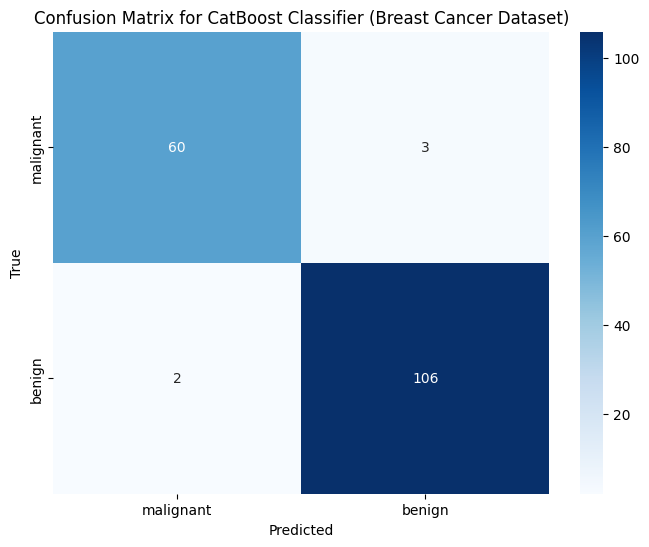

Plotting complete.


In [12]:
#Question 9:
'''
Write a Python program to:
● Train a CatBoost Classifier
● Plot the confusion matrix using seaborn
'''


import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# Install CatBoost if not already installed
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


# 1. Load the Breast Cancer dataset
print("Loading Breast Cancer dataset...")
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Data split into: Train samples ({len(X_train)}), Test samples ({len(X_test)})")

# 3. Initialize and train the CatBoost Classifier
# CatBoost handles categorical features automatically, but for Breast Cancer, all features are numerical.
# We set 'verbose=0' to suppress training output, and 'random_state' for reproducibility.
print("Training CatBoost Classifier...")
cat_model = CatBoostClassifier(iterations=100,  # Number of boosting rounds
                               learning_rate=0.1,
                               depth=6,         # Depth of the tree
                               loss_function='Logloss', # For binary classification
                               eval_metric='Accuracy',
                               random_seed=42,
                               verbose=0) # Suppress verbose output during training

cat_model.fit(X_train, y_train)
print("Training complete.")

# 4. Make predictions on the test set
y_pred = cat_model.predict(X_test)

# 5. Calculate and print accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "-" * 40)
print(f"CatBoost Classifier Accuracy on Test Set: {accuracy * 100:.2f}%")
print("-" * 40)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 6. Plot the confusion matrix
print("\nPlotting Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for CatBoost Classifier (Breast Cancer Dataset)')
plt.show()
print("Plotting complete.")


#Question 10:
You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.

Describe your step-by-step data science pipeline using boosting techniques:

● Data preprocessing & handling missing/categorical values

● Choice between AdaBoost, XGBoost, or CatBoost

● Hyperparameter tuning strategy

● Evaluation metrics you'd choose and why

● How the business would benefit from your model

#Ans:-  
*   **Data Preprocessing and Handling:**
    *   **Missing Values:** Recommended median imputation for numerical features (robust to outliers) and mode imputation or a dedicated 'missing' category for categorical features.
    *   **Categorical Features:** Suggested One-Hot Encoding for nominal features, Target Encoding for high-cardinality features (with caution against leakage), and leveraging CatBoost's native handling when using that algorithm.
    *   **Data Imbalance:** Proposed **class weights** as the primary strategy within boosting models, with SMOTE for oversampling (applied to training data only) as an alternative or supplementary method.

*   **Choice of Boosting Algorithm:**
    *   **CatBoost** was recommended over AdaBoost and XGBoost for loan default prediction due to its:
        *   **Native handling of categorical features**, reducing preprocessing complexity and avoiding target leakage.
        *   **Robustness to imbalanced datasets** via built-in class weight mechanisms.
        *   **Native handling of missing values**, simplifying the pipeline.
        *   **Reduced overfitting** through its ordered boosting scheme.

*   **Hyperparameter Tuning Strategy:**
    *   **Method:** **RandomizedSearchCV** was recommended over GridSearchCV for efficiency in exploring CatBoost's complex parameter space.
    *   **Parameter Grid:** Key hyperparameters for tuning include `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `random_strength`, `border_count`, `bagging_temperature`, and crucially, `class_weights`.
    *   **Imbalanced Data Metrics:** Emphasized using **F1-score** (or F-beta scores, with F2 for higher recall priority), **AUC-ROC**, and especially **AUPRC (Area Under the Precision-Recall Curve)** as primary scoring metrics during tuning, as accuracy is misleading for imbalanced data.

*   **Evaluation Metrics and Justification:**
    *   **Accuracy:** Deemed insufficient and misleading for highly imbalanced loan default datasets.
    *   **Key Metrics:** **Precision**, **Recall**, **F1-Score** (or F-beta scores like F2-score for higher recall emphasis), **AUC-ROC**, and **AUPRC** were identified as critical.
    *   **Business Relevance:** These metrics are crucial for:
        *   Minimizing **False Negatives** (missed defaulters) which lead to direct financial losses (addressed by Recall, F2-score, AUPRC).
        *   Minimizing **False Positives** (incorrectly denied loans to creditworthy customers) which lead to lost business opportunities (addressed by Precision, F0.5-score).
        *   Providing an overall model discrimination ability (AUC-ROC).

*   **Business Benefits of the Model:**
    *   **Improved Risk Assessment:** Enables more accurate identification of high-risk applicants, mitigating losses and expanding lending to low-risk profiles.
    *   **Optimized Lending Decisions:** Provides data-driven insights for setting optimal loan terms and interest rates.
    *   **Reduction in Financial Losses:** Directly prevents costly defaults, saving on write-offs and collection costs.
    *   **Enhanced Customer Segmentation:** Allows for targeted product development and personalized support based on risk profiles.
    *   **Better Resource Allocation:** Frees up human resources from manual tasks for more strategic analysis and optimizes marketing efforts.

### Insights or Next Steps

*   The chosen **CatBoost** model, combined with robust preprocessing (especially class weights for imbalance) and hyperparameter tuning using business-aligned metrics like AUPRC or F2-score, forms a solid foundation for a performant and fiscally responsible loan default prediction system.
*   Moving forward, it would be beneficial to conduct a detailed cost-benefit analysis of False Positives versus False Negatives to determine the optimal F-beta score or classification threshold that maximizes profitability for the FinTech company.
